In [2]:
import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

Module - это абстрактный класс, который определяет фундаментальные методы, необходимые для обучения нейронной сети. Вам не нужно ничего здесь менять, просто прочитайте комментарии.

In [3]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)

        В принципе, вы можете представить себе модуль как нечто (черный ящик)
    , которое может обрабатывать "входные" данные и выдавать "выходные" данные.
    Это похоже на применение функции, которая называется `forward`:

        output = модуль.forward (ввод)

    Модуль должен уметь выполнять обратный переход: чтобы отличить функцию "forward".
    Более того, он должен уметь отличать ее, если она является частью цепочки (правило цепочки).
    Последнее подразумевает, что существует отклонение от предыдущего шага правила цепочки.

        gradInput = модуль.обратный(ввод, gradOutput)

    """
    def __init__ (self):
        self.output = None  #хранит результат прямого прохода (выходное значение)
        self.gradInput = None #хранит градиент по входу ( обратный проход)
        self.training = True #показывает работает модель в режиме обучения (True) или в режиме оценки (False)

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.

        Принимает входной объект и вычисляет соответствующий выходной сигнал модуля.

        """
        return self.updateOutput(input)

        # Вызывает updateOutput(input), переопределена в дочерних классах.
        # Задача: вычислить выходное значение (output) на основе входа.
    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).

        Выполняет шаг обратного распространения по модулю в соответствии с заданными входными данными.

        Это включает
         - вычисление градиента с использованием `входных данных" (необходимо для дальнейшей обратной обработки),
         - вычисление градиента с параметрами (для обновления параметров при оптимизации).
        """
        #вызываем два метода
        self.updateGradInput(input, gradOutput) #вычислить градиент по входу
        self.accGradParameters(input, gradOutput) #вычислить градиент по параметрам, но только если они есть
        #возвращаем градиент по входу
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.

        Вычисляет выходные данные, используя текущий набор параметров класса и входные данные.
        Эта функция возвращает результат, который сохраняется в поле "Выходные данные".

        Убедитесь в том, что вы сохранили данные как в поле "вывод", так и вернули их.
        """

        # The easiest case(пример самого простого модуля — "передай вход на выход без изменений"):

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.

        Вычисление градиента модуля относительно его собственных входных данных.
        Это значение возвращается в `gradInput`. Кроме того, переменная состояния `gradInput` обновляется соответствующим образом.

        Форма `gradInput` всегда совпадает с формой `input`.

        Убедитесь, что градиенты сохраняются в поле `gradInput` и возвращаются обратно.
        """

        # The easiest case(Пример для модуля, который не меняет данные (провод). В этом случае градиент по входу равен градиенту по выходу.):

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).

        Вычисление градиента модуля относительно его собственных параметров.
        Нет необходимости переопределять, если модуль не имеет параметров (например, ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.

        Обнуляет переменную gradParams, если в модуле есть параметры.

        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.

        Возвращает список с его параметрами.
        Если модуль не имеет параметров, то возвращается пустой список.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.

        Возвращает список с градиентами относительно его параметров.
        Если модуль не имеет параметров, возвращает пустой список.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.

        Устанавливает режим обучения для модуля.
        Поведение при обучении и тестировании отличается в случае отсева и пакетной нормы.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.

        Устанавливает режим оценки для модуля.
        Поведение при обучении и тестировании отличается в зависимости от отсева и пакетной нормы.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.

        Красивая печать. Должно быть переопределено в каждом модуле, если вы хотите
        чтобы иметь удобочитаемое описание.
        """
        return "Module"

# Sequential container

контейнер, который объединяет модули в последовательную цепочку

:**Define** a forward and backward pass procedures.

Определите процедуры прямого и обратного прохода.

In [4]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.

         Этот класс реализует контейнер, который последовательно обрабатывает "входные" данные.

         "входные" данные обрабатываются каждым модулем (слоем) в self.modules последовательно.
         Результирующий массив называется `выходным`.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.

        Добавляет модуль в контейнер.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        """
        Basic workflow of FORWARD PASS:

            y_0    = module[0].forward(input)
            y_1    = module[1].forward(y_0)
            ...
            output = module[n-1].forward(y_{n-2})


        Just write a little loop.

        Основной рабочий процесс ПРЯМОГО ПРОХОДА:

            y_0 = модуль[0].forward(ввод)
            y_1 = модуль[1].forward(y_0)
            ...
            output = модуль[n-1].forward(y_{n-2})


        Просто напишите небольшой цикл.
        """

        # Your code goes here. ################################################
        self.inputs = [input] # сохраняем входы для backward
        self.output = input

        for module in self.modules: # делаем прогонку данных на входе через все слои
            self.output = module.forward(self.output) # наш результат прогонки передаем на вход следующего слоя
            self.inputs.append(self.output) #сохранили

        return self.output

        #1 варик
        #self.inputs = [input] # сохраняем входы для backward

        #self.output = input
        #for module in self.modules:
        #    self.output = module.forward(self.output)
        #    self.inputs.append(self.output)

        #return self.output


    def backward(self, input, gradOutput):
        """
        Workflow of BACKWARD PASS:

            g_{n-1} = module[n-1].backward(y_{n-2}, gradOutput)
            g_{n-2} = module[n-2].backward(y_{n-3}, g_{n-1})
            ...
            g_1 = module[1].backward(y_0, g_2)
            gradInput = module[0].backward(input, g_1)


        !!!

        To ech module you need to provide the input, module saw while forward pass,
        it is used while computing gradients.
        Make sure that the input for `i-th` layer the output of `module[i]` (just the same input as in forward pass)
        and NOT `input` to this Sequential module.

        !!!
         Рабочий процесс ОБРАТНОГО ПРОХОДА:

            g_{n-1} = модуль[n-1].обратный(y_{n-2}, градуированный вывод)
            g_{n-2} = модуль[n-2].в обратном направлении(y_{n-3}, g_{n-1})
            ...
            g_1 = модуль[1].в обратном направлении(y_0, g_2)
            gradInput = module[0].обратный ввод(input, g_1)


        !!!

        Модулю ech необходимо предоставить входные данные, которые модуль видел при прямом проходе,
        они используются при вычислении градиентов.
        Убедитесь, что входные данные для "i-го" соответствуют выходным данным "модуля [i]" (точно таким же входным данным, как и в прямом проходе)
        а не "входным данным" для этого последовательного модуля.

        !!!
        """
        # Your code goes here. ################################################
        grad = gradOutput #начинаем с градиента, который пришёл сверху (от следующего слоя или loss)

        for i in reversed(range(len(self.modules))):  # идём по слоям в обратном порядке (с конца к началу)
            grad = self.modules[i].backward(self.inputs[i], grad)

        self.gradInput = grad
        return self.gradInput


    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        """
        Should gather all parameters in a list.

        Следует собрать все параметры в список.
        """
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.

        Следует собрать все градиенты с параметрами rt в список.
        """
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        """
        Propagates training parameter through all modules

        Распространяет обучающий параметр по всем модулям
        """
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        """
        Propagates training parameter through all modules

        Распространяет обучающий параметр по всем модулям
        """
        self.training = False
        for module in self.modules:
            module.evaluate()

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

Также известен как плотный слой, полносвязный слой, FC-слой, слой внутреннего произведения, аффинное преобразование

вход: batch_size x n_feats1

выход: batch_size x n_feats2

In [5]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).

    Модуль, применяющий линейное преобразование
    Обычно называется полносвязным слоем, InnerProductLayer в caffe.

    Модуль должен работать с двумерными входными данными формы (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization

        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Your code goes here. ################################################
        #if input.ndim == 1:
         # input = input.reshape(1, -1)
        # считаем y = xW + b
        self.output = np.dot(input, self.W.T) + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # градиент по входу: dL/dx = gradOutput * W^T
        # Your code goes here. ################################################
        self.gradInput = np.dot(gradOutput, self.W)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Your code goes here. ################################################
        # градиент по весам: dL/dW = x^T * gradOutput
        self.gradW += np.dot(gradOutput.T, input)

        # градиент по bias: сумма по батчу
        self.gradb += np.sum(gradOutput, axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [6]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        #Начнем с нормализации для обеспечения численной устойчивости
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        np.exp(self.output, out=self.output) # вычисление экспоненты
        np.divide(self.output, self.output.sum(axis=1, keepdims=True), out=self.output)

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput * self.output
        np.subtract(self.gradInput, self.output * self.gradInput.sum(axis=1, keepdims=True), out=self.gradInput) # корректируем

        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [7]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        log_sum_exp = np.log(np.exp(self.output).sum(axis=1, keepdims=True))
        self.output = np.subtract(self.output, log_sum_exp)

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        softmax_grad = np.exp(self.output) / np.sum(np.exp(self.output), axis=1, keepdims=True)
        self.gradInput = gradOutput - softmax_grad * np.sum(gradOutput, axis=1, keepdims=True)

        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

4. (0,3) Пакетная нормализация
Одна из самых важных идей последнего времени, которая сильно повлияла на нейронные сети, — это пакетная нормализация. Идея проста, но эффективна: признаки должны быть «отбелены» (среднее значение = 0, стандартное отклонение = 1) на всех этапах работы нейронной сети. Это улучшает сходимость глубоких моделей, позволяя обучать их в течение нескольких дней, а не недель. Вам нужно реализовать первую часть слоя — нормализацию признаков. Вторая часть (слой ChannelwiseScaling) реализована ниже.

входные данные: batch_size x n_feats
выходные данные: batch_size x n_feats
Слой должен работать следующим образом. Во время обучения (self.training == True) он преобразует входные данные следующим образом:

где  μ  и  σ  — среднее значение и дисперсия значений признаков в пакете, а  ϵ  — небольшое число для обеспечения числовой стабильности. Кроме того, во время обучения слой должен поддерживать экспоненциальные скользящие средние значения для среднего и дисперсии:

    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
Во время тестирования (self.training == False) слой нормализует входные данные с помощью moving_mean и moving_variance.

Обратите внимание, что разделение пакетной нормализации на собственно нормализацию и поканальное масштабирование — это просто распространенный подход к реализации. В целом «пакетная нормализация» всегда предполагает нормализацию + масштабирование.

In [8]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha

        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        # use self.EPS please
        if self.training:

            self.batch_mean = input.mean(axis=0)
            self.batch_var = input.var(axis=0)

            self.output = (input - self.batch_mean) / np.sqrt(self.batch_var + self.EPS)

            if self.moving_mean is None:
                self.moving_mean = self.batch_mean
                self.moving_variance = self.batch_var
            else:

                self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
                self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * self.batch_var

        else:

            # используем накопленные статистики, а не текущий батч
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        N = input.shape[0]  # размер батча

        batch_var = self.batch_var + self.EPS
        std_inv = 1. / np.sqrt(batch_var)
        x_centered = input - self.batch_mean
        self.gradInput = (1. / N) * std_inv * (
            N * gradOutput
            - np.sum(gradOutput, axis=0)
            - x_centered * np.sum(gradOutput * x_centered, axis=0) / batch_var
        )
        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"

In [9]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \\gamma * x + \\beta
       where \\gamma, \\beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

Практические замечания:
Если BatchNormalization размещается после линейного преобразования (включая полносвязный слой, сверточные слои, поканальное масштабирование), которое реализует функцию вида:

y = weight * x + bias

то добавление смещения (bias) становится бесполезным и может быть опущено, так как его эффект будет уничтожен при вычитании среднего значения в Batch Normalization.

Если BatchNormalization (за которым следует ChannelwiseScaling) размещается перед слоем, который сохраняет масштаб (например, ReLU, LeakyReLU), а затем следует любой линейный слой, то параметр gamma в ChannelwiseScaling` можно зафиксировать (заморозить), так как он может быть поглощен (перенесен) в линейный слой.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

Идея и реализация очень просты: просто умножьте вход на маску Bernoulli(p). Здесь p — вероятность того, что элемент будет обнулен.

Доказано, что это эффективный метод регуляризации и предотвращения коадаптации нейронов.

Во время обучения (self.training == True) он должен выбирать маску на каждой итерации (для каждого батча), обнулять элементы и умножать элементы на
. Последнее необходимо для поддержания средних значений признаков близкими к средним значениям, которые будут в тестовом режиме. При тестировании этот модуль должен реализовать тождественное преобразование, то есть self.output = input.

In [10]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p #вероятность "выключить" нейрон
        self.mask = None #маска, которая будет хранить какие нейроны оставили

    def updateOutput(self, input):
        # Your code goes here. ################################################
        if self.training:
            #создаём маску:
            #1 - нейрон оставляем
            #0 - нейрон выключаем
            #делим на (1-p), чтобы сохранить масштаб значений
            self.mask = np.random.binomial(1, 1 - self.p, size=input.shape) / (1 - self.p)

            # применяем маску к входу (зануляем часть нейронов)
            self.output = input * self.mask
        else:
            self.output = input

        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################

        if self.training:
            # градиент проходит только через "живые" нейроны (те, где mask != 0)

            self.gradInput = gradOutput * self.mask
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride(может быть 1 и 2), padding("SAME" и "VALIDE", zero), bias, padding_mode=zero) and fix dilation=1 and groups=1.
в матричной форме, матричное умножение!!
свертки неоч

In [11]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True, padding_mode='zeros'):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding
        self.padding_mode = padding_mode

        stdv = 1. / np.sqrt(in_channels * self.kernel_size[0] * self.kernel_size[1])
        self.weight = np.random.uniform(-stdv, stdv, (out_channels, in_channels, *self.kernel_size))
        self.bias = np.random.uniform(-stdv, stdv, out_channels) if bias else None
        self.gradWeight = np.zeros_like(self.weight)
        self.gradBias = np.zeros_like(self.bias) if bias else None

        #для хранения промежуточных данных
        self.x_pad = None
        self.pad_params = None

    def _get_padding(self, H, W):
        k_h, k_w = self.kernel_size
        s_h, s_w = self.stride

        if self.padding == 'same':
            out_h = (H + s_h - 1) // s_h
            out_w = (W + s_w - 1) // s_w
            pad_h = max((out_h - 1) * s_h + k_h - H, 0)
            pad_w = max((out_w - 1) * s_w + k_w - W, 0)
            return pad_h // 2, pad_h - pad_h // 2, pad_w // 2, pad_w - pad_w // 2
        elif self.padding == 'valid':
            return 0, 0, 0, 0
        else:
            if isinstance(self.padding, int):
                p = self.padding
            elif isinstance(self.padding, tuple):
                p = self.padding[0]
            else:
                p = 0
            return p, p, p, p

    def updateOutput(self, input):
        self.input = input
        N, C, H, W = input.shape
        k_h, k_w = self.kernel_size
        s_h, s_w = self.stride

        pt, pb, pl, pr = self._get_padding(H, W)
        self.pad_params = (pt, pb, pl, pr)

        #применяем паддинг
        if pt == 0 and pb == 0 and pl == 0 and pr == 0:
            self.x_pad = input
        else:
            if self.padding_mode == 'zeros':
                self.x_pad = np.pad(input, ((0,0),(0,0),(pt,pb),(pl,pr)), mode='constant', constant_values=0)
            elif self.padding_mode == 'reflect':
                self.x_pad = np.pad(input, ((0,0),(0,0),(pt,pb),(pl,pr)), mode='reflect')
            elif self.padding_mode == 'replicate':
                self.x_pad = np.pad(input, ((0,0),(0,0),(pt,pb),(pl,pr)), mode='edge')
            else:
                self.x_pad = np.pad(input, ((0,0),(0,0),(pt,pb),(pl,pr)), mode='constant', constant_values=0)

        H_pad, W_pad = self.x_pad.shape[2], self.x_pad.shape[3]
        out_h = (H_pad - k_h) // s_h + 1
        out_w = (W_pad - k_w) // s_w + 1

        #im2col
        self.x_cols = np.zeros((N, C * k_h * k_w, out_h * out_w))
        idx = 0
        for i in range(0, H_pad - k_h + 1, s_h):
            for j in range(0, W_pad - k_w + 1, s_w):
                self.x_cols[:, :, idx] = self.x_pad[:, :, i:i+k_h, j:j+k_w].reshape(N, -1)
                idx += 1

        out = self.weight.reshape(self.out_channels, -1) @ self.x_cols

        if self.bias is not None:
            out += self.bias.reshape(-1, 1)

        self.output = out.reshape(N, self.out_channels, out_h, out_w)
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        k_h, k_w = self.kernel_size
        s_h, s_w = self.stride
        pt, pb, pl, pr = self.pad_params

        N, C_out, H_out, W_out = gradOutput.shape

        #C_out, N * H_out * W_out
        grad_flat = gradOutput.transpose(1, 0, 2, 3).reshape(C_out, -1)

        W_flat = self.weight.reshape(C_out, -1)
        grad_cols = W_flat.T @ grad_flat

        H_pad, W_pad = H + pt + pb, W + pl + pr
        grad_pad = np.zeros((N, C, H_pad, W_pad))

        idx = 0
        for i in range(0, H_pad - k_h + 1, s_h):
            for j in range(0, W_pad - k_w + 1, s_w):
                col_data = grad_cols[:, idx::(H_out * W_out)].reshape(C, k_h, k_w, N)
                col_data = col_data.transpose(3, 0, 1, 2)  # (N, C, k_h, k_w)
                grad_pad[:, :, i:i+k_h, j:j+k_w] += col_data
                idx += 1


        if pt > 0 or pb > 0 or pl > 0 or pr > 0:
            if pb == 0:
                self.gradInput = grad_pad[:, :, pt:, pl:]
            elif pr == 0:
                self.gradInput = grad_pad[:, :, pt:-pb, pl:]
            else:
                self.gradInput = grad_pad[:, :, pt:-pb, pl:-pr]
        else:
            self.gradInput = grad_pad

        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        N, C_out, H_out, W_out = gradOutput.shape

        grad_flat = gradOutput.transpose(1, 0, 2, 3).reshape(C_out, -1)

        x_cols_flat = self.x_cols.transpose(1, 0, 2).reshape(-1, N * H_out * W_out)
        self.gradWeight = (grad_flat @ x_cols_flat.T).reshape(self.weight.shape)

        if self.bias is not None:
            self.gradBias = grad_flat.sum(axis=1)

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.bias is not None:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.bias is not None:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.bias is not None:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]
    def __repr__(self):
        return "Conv2d"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [12]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
      # Your code goes here. ################################################
        #добавляем padding по высоте и ширине
        self.input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)),
            mode='constant'
        )

        batch_size, channels, H, W = self.input_padded.shape

        #размер выхода
        out_H = (H - self.kernel_size) // self.stride + 1
        out_W = (W - self.kernel_size) // self.stride + 1

        #создаём выход и массив для индексов максимумов
        self.output = np.zeros((batch_size, channels, out_H, out_W))
        self.max_indices = np.zeros((batch_size, channels, out_H, out_W), dtype=int)

        #основной цикл pooling
        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_H):
                    for j in range(out_W):
                        #координаты окна
                        h_start = i * self.stride
                        w_start = j * self.stride

                        #вырезаем окно
                        window = self.input_padded[
                            b, c,
                            h_start:h_start + self.kernel_size,
                            w_start:w_start + self.kernel_size
                        ]

                        #берём максимум
                        self.output[b, c, i, j] = np.max(window)

                        #сохраняем индекс максимума
                        self.max_indices[b, c, i, j] = np.argmax(window)

        return self.output

    def updateGradInput(self, input, gradOutput):
      # Your code goes here. ################################################
        #создаём градиент
        gradInput_padded = np.zeros_like(self.input_padded)

        batch_size, channels, out_H, out_W = gradOutput.shape

        #распределяем градиент
        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_H):
                    for j in range(out_W):

                        idx = self.max_indices[b, c, i, j] #индекс максимума в окне

                        h_idx = idx // self.kernel_size
                        w_idx = idx % self.kernel_size

                        h_start = i * self.stride
                        w_start = j * self.stride

                        gradInput_padded[b, c, h_start + h_idx, w_start + w_idx] += gradOutput[b, c, i, j]

        if self.padding > 0:
            self.gradInput = gradInput_padded[
                :, :,
                self.padding:-self.padding,
                self.padding:-self.padding
            ]
        else:
            self.gradInput = gradInput_padded

        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"

In [13]:
class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
      # Your code goes here. ################################################
        #добавляем паддинг
        self.input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)),
            mode='constant'
        )

        batch_size, channels, H, W = self.input_padded.shape

        #наш размер выхода
        out_H = (H - self.kernel_size) // self.stride + 1
        out_W = (W - self.kernel_size) // self.stride + 1

        self.output = np.zeros((batch_size, channels, out_H, out_W))

        #считаем среднее по каждому окну
        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_H):
                    for j in range(out_W):
                        h_start = i * self.stride
                        w_start = j * self.stride

                        window = self.input_padded[
                            b, c,
                            h_start:h_start + self.kernel_size,
                            w_start:w_start + self.kernel_size
                        ]

                        #среднее значение
                        self.output[b, c, i, j] = np.mean(window)

        return self.output

    def updateGradInput(self, input, gradOutput):
      # Your code goes here. ################################################
        #создаём градиент
        gradInput_padded = np.zeros_like(self.input_padded)

        batch_size, channels, out_H, out_W = gradOutput.shape

        #делим градиент равномерно
        div = self.kernel_size * self.kernel_size

        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_H):
                    for j in range(out_W):
                        h_start = i * self.stride
                        w_start = j * self.stride

                        #равномерное распределение градиента
                        grad = gradOutput[b, c, i, j] / div

                        gradInput_padded[
                            b, c,
                            h_start:h_start + self.kernel_size,
                            w_start:w_start + self.kernel_size
                        ] += grad

        if self.padding > 0:
            self.gradInput = gradInput_padded[
                :, :,
                self.padding:-self.padding,
                self.padding:-self.padding
            ]
        else:
            self.gradInput = gradInput_padded

        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

8. (0,3) Реализуйте GlobalMaxPool2d и GlobalAvgPool2d. У них нет тестирования, а параметры вы определяете сами, но они должны объединять информацию по каналам. Напишите тестовые функции для этих слоев самостоятельно.

In [14]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()

    def updateOutput(self, input):
        self.input_shape = input.shape
        N, C, H, W = input.shape

        #превращаем (H, W) в одно измерение
        input_reshaped = input.reshape(N, C, -1)

        #берём максимум по каждому каналу
        self.output = np.max(input_reshaped, axis=2)  #(N, C)

        #сохраняем позиции максимумов
        self.max_indices = np.argmax(input_reshaped, axis=2)

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = self.input_shape
        #создаём нулевой градиент
        grad = np.zeros((N, C, H * W))

        #градиент идёт ТОЛЬКО в максимум
        for n in range(N):
            for c in range(C):
                idx = self.max_indices[n, c]
                grad[n, c, idx] = gradOutput[n, c]

        self.gradInput = grad.reshape(N, C, H, W)

        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"

In [15]:
class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()

    def updateOutput(self, input):
        self.input_shape = input.shape
        N, C, H, W = input.shape

        #среднее по H и W
        self.output = np.mean(input, axis=(2, 3))

        return self.output  #(N, C)

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = self.input_shape

        #каждый элемент получает одинаковую долю градиента
        grad = gradOutput[:, :, None, None] / (H * W)

        #растягиваем до исходного размера
        self.gradInput = np.ones((N, C, H, W)) * grad

        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

тестики

In [16]:
def test_GlobalMaxPool2d():
    params_list = [
        {'batch_size': 2, 'channels': 3, 'height': 4, 'width': 4},
        {'batch_size': 1, 'channels': 1, 'height': 2, 'width': 2},
    ]

    for params in params_list:
        print(f"Testing GlobalMaxPool2d with params: {params}")
        pool = GlobalMaxPool2d()

        x = np.random.randn(
            params['batch_size'],
            params['channels'],
            params['height'],
            params['width']
        )

        output = pool.updateOutput(x)
        assert output.shape == (params['batch_size'], params['channels'])

        expected = np.max(x.reshape(params['batch_size'], params['channels'], -1), axis=2)
        assert np.allclose(output, expected)

        grad_output = np.ones_like(output)
        grad_input = pool.updateGradInput(x, grad_output)

        expected_grad = np.zeros_like(x)
        reshaped = x.reshape(params['batch_size'], params['channels'], -1)

        for n in range(params['batch_size']):
            for c in range(params['channels']):
                idx = np.argmax(reshaped[n, c])
                h = idx // params['width']
                w = idx % params['width']
                expected_grad[n, c, h, w] = 1

        assert np.allclose(grad_input, expected_grad)

        print("GlobalMaxPool2d OK\n")

In [17]:
def test_GlobalAvgPool2d():
    params_list = [
        {'batch_size': 2, 'channels': 3, 'height': 4, 'width': 4},
        {'batch_size': 1, 'channels': 1, 'height': 2, 'width': 2},
    ]

    for params in params_list:
        print(f"Testing GlobalAvgPool2d with params: {params}")
        pool = GlobalAvgPool2d()

        x = np.random.randn(
            params['batch_size'],
            params['channels'],
            params['height'],
            params['width']
        )

        output = pool.updateOutput(x)
        assert output.shape == (params['batch_size'], params['channels'])

        expected = np.mean(x, axis=(2, 3))
        assert np.allclose(output, expected)

        grad_output = np.ones_like(output)
        grad_input = pool.updateGradInput(x, grad_output)

        expected_grad = np.ones_like(x) / (params['height'] * params['width'])

        assert np.allclose(grad_input, expected_grad)

        print("GlobalAvgPool2d OK\n")

In [18]:
test_GlobalMaxPool2d()
test_GlobalAvgPool2d()

print("ALL TESTS PASSED")

Testing GlobalMaxPool2d with params: {'batch_size': 2, 'channels': 3, 'height': 4, 'width': 4}
GlobalMaxPool2d OK

Testing GlobalMaxPool2d with params: {'batch_size': 1, 'channels': 1, 'height': 2, 'width': 2}
GlobalMaxPool2d OK

Testing GlobalAvgPool2d with params: {'batch_size': 2, 'channels': 3, 'height': 4, 'width': 4}
GlobalAvgPool2d OK

Testing GlobalAvgPool2d with params: {'batch_size': 1, 'channels': 1, 'height': 2, 'width': 2}
GlobalAvgPool2d OK

ALL TESTS PASSED


#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [19]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.input_shape = input.shape

        start_dim = self.start_dim if self.start_dim >= 0 else len(input.shape) + self.start_dim
        end_dim = self.end_dim if self.end_dim >= 0 else len(input.shape) + self.end_dim

        new_shape = (input.shape[:start_dim] + (-1,) + input.shape[end_dim + 1:])
        self.output = input.reshape(new_shape)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [20]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [21]:
class LeakyReLU(Module):
    def __init__(self, slope=0.03):
        super(LeakyReLU, self).__init__()
        self.slope = slope  # коэффициент для отрицательных значений (обычно маленький)

    def updateOutput(self, input):
      # Your code goes here. ################################################
        #если x>0 то оставляем как есть
        #если x<=0 то умножаем на slope (не обнуляем полностью, как в ReLU)

        #(input>0) даёт маску из 1 и 0
        #(input<=0) - противоположная маска

        self.output = input * (input > 0) + self.slope * input * (input <= 0)

        return self.output

    def updateGradInput(self, input, gradOutput):
      # Your code goes here. ################################################
        #градиент:
        #если x>0 то производная=1
        #если x<=0 то производная=slope

        #умножаем внешний градиент на производную функции
        self.gradInput = gradOutput * ((input > 0) + self.slope * (input <= 0))

        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [22]:
class ELU(Module):
    def __init__(self, alpha=1.0):
        super(ELU, self).__init__()

        self.alpha = alpha  #коэффициент для отрицательной части

    def updateOutput(self, input):
      # Your code goes here. ################################################

        #если x>0 получаем x
        #если x<=0 то alpha*(exp(x)-1)

        #np.where делает поэлементный выбор:для каждого x выбирается формула в зависимости от условия
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))

        return self.output

    def updateGradInput(self, input, gradOutput):
      # Your code goes here. ################################################

        #производная ELU:
        #если x > 0 то 1
        #если x <= 0 то alpha*exp(x)

        # важный момент!:
        #alpha*exp(x)=output+alpha следует из формулы ELU)

        # поэтому можно использовать self.output вместо expх
        self.gradInput = np.where(
            input > 0,
            gradOutput,  #производная=1
            gradOutput * (self.output + self.alpha)  #производная=alpha*exp(x)
        )

        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [23]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
      # Your code goes here. ################################################
        #log(1 + exp(x)) но в лоб считать нельзя тк exp(x) может переполниться при больших x

        #возьму более стабильную формулу: log(1 + exp(x)) = max(0, x) + log(1 + exp(-|x|))
        #где max(0, x) — берём положительную часть
        max_part = np.maximum(0, input)
        log_part = np.log(1 + np.exp(-np.abs(input)))
        self.output = max_part + log_part

        return self.output

    def updateGradInput(self, input, gradOutput):
      # Your code goes here. ################################################
        #производная d/dxlog(1+exp(x))= sigmoid(x)
        sigmoid = 1 / (1 + np.exp(-input))
        self.gradInput = gradOutput * sigmoid

        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

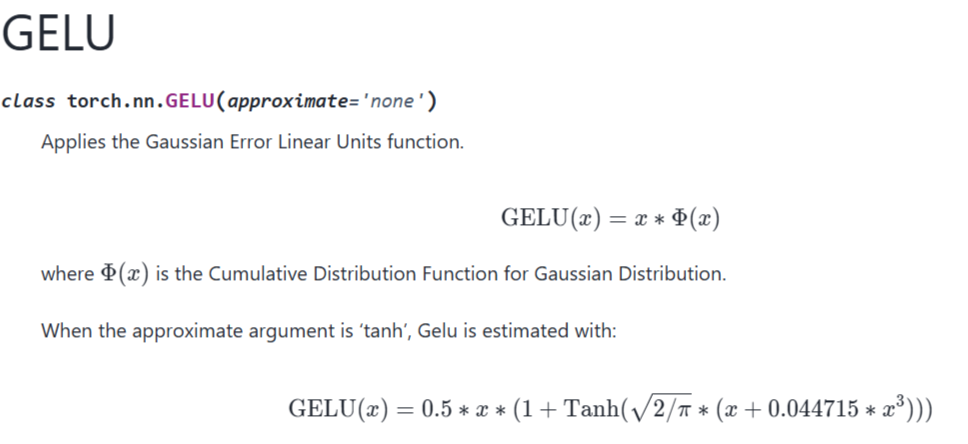

In [24]:
class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        # Your code goes here. ################################################
        c = np.sqrt(2 / np.pi)
        self.output = 0.5 * input * (1 + np.tanh(c * (input + 0.044715 * np.power(input, 3))))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        c = np.sqrt(2 / np.pi)
        tan = np.tanh(c * (input + 0.044715 * input**3))
        sec = 1 - tan**2
        gelu_grad = 0.5 * (1 + tan) + 0.5 * input * sec * c * (1 + 3 * 0.044715 * np.power(input, 2))
        self.gradInput = gradOutput * gelu_grad
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [25]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.
            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.

            Данный вход и целевое значение, вычислить функцию потерь, связанную с критерием, и вернуть результат.
            Для согласованности эта функция не должна переопределяться, весь код должен быть размещен в `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.

            Данный вход и целевое значение, вычислить градиенты функции потерь, связанные с критерием, и вернуть результат.
            Для согласованности эта функция не должна переопределяться, весь код должен быть размещен в `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override. Функция для переопределения.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override. Функция для переопределения.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.

        Красивое представление. Должно быть переопределено в каждом модуле, если вы хотите получить читаемое описание.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [26]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [27]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15 #маленькое число, чтобы избежать log(0) и деления на 0
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS) #ограничиваем значения, чтобы не было log(0)

        # Your code goes here. ################################################
        self.output = -np.sum(target * np.log(input_clamp)) / input.shape[0]

        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################

        self.gradInput = -target / (input_clamp * input.shape[0])

        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [28]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        self.output = -np.sum(target * input) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        self.gradInput = -target / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.


In [29]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
import seaborn as sns

### Оптимизатор

In [30]:
class SGD:
    def __init__(self, model, lr=0.001, momentum=0.9, weight_decay=0):
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.modules = model.layers.modules

        self.params = []
        for module in self.modules:
            if hasattr(module, 'W'):
                self.params.append(module.W)
            if hasattr(module, 'b'):
                self.params.append(module.b)
            if hasattr(module, 'gamma'):
                self.params.append(module.gamma)
            if hasattr(module, 'beta'):
                self.params.append(module.beta)

        self.v = [np.zeros_like(p) for p in self.params]

    def step(self):

        idx = 0

        #проходим по всем слоям модели
        for module in self.modules:
            if hasattr(module, 'W') and hasattr(module, 'gradW') and module.gradW is not None:
                grad = module.gradW  #берем градиент по весам
                #добавляем штраф
                if self.weight_decay > 0:
                    grad = grad + self.weight_decay * module.W

                self.v[idx] = self.momentum * self.v[idx] + grad
                module.W -= self.lr * self.v[idx]

                idx += 1
            if hasattr(module, 'b') and hasattr(module, 'gradb') and module.gradb is not None:
                grad = module.gradb

                if len(grad.shape) > 1:
                    grad = grad.mean(axis=0)

                self.v[idx] = self.momentum * self.v[idx] + grad
                module.b -= self.lr * self.v[idx]
                idx += 1

            if hasattr(module, 'gamma') and hasattr(module, 'gradGamma') and module.gradGamma is not None:
                self.v[idx] = self.momentum * self.v[idx] + module.gradGamma
                module.gamma -= self.lr * self.v[idx]
                idx += 1


            if hasattr(module, 'beta') and hasattr(module, 'gradBeta') and module.gradBeta is not None:
                self.v[idx] = self.momentum * self.v[idx] + module.gradBeta
                module.beta -= self.lr * self.v[idx]
                idx += 1

    def zero_grad(self):

        for module in self.modules:
            if hasattr(module, 'gradW'):
                module.gradW.fill(0)
            if hasattr(module, 'gradb'):
                module.gradb.fill(0)
            if hasattr(module, 'gradGamma'):
                module.gradGamma.fill(0)
            if hasattr(module, 'gradBeta'):
                module.gradBeta.fill(0)

### Задача мультирегрессии

In [31]:
np.random.seed(42)
n_samples = 20000
n_features = 10
n_targets = 3

X = np.random.randn(n_samples, n_features) * np.random.uniform(0.5, 3.0, size=(n_features,))
true_weights = np.random.randn(n_features, n_targets)
nonlinear_part = np.sin(X[:, :3])
nonlinear_weights = np.random.randn(3, n_targets)

y = (X @ true_weights + 0.5 * nonlinear_part @ nonlinear_weights + 0.1 * np.random.randn(n_samples, n_targets))

наша выборка

In [32]:
indices = np.random.permutation(n_samples)
train_end = int(0.7 * n_samples)
val_end = int(0.85 * n_samples)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]


In [33]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(14000, 10) (14000, 3)
(3000, 10) (3000, 3)
(3000, 10) (3000, 3)


маленькая модель

In [34]:
class SmallRegressionModel(Module):
    def __init__(self, input_size, hidden_size=64, output_size=3, dropout_p=0.2):
        super().__init__()

        self.layers = Sequential()

        #ПЕРВЫЙ СЛОЙ
        self.layers.add(Linear(input_size, hidden_size))
        self.layers.add(BatchNormalization(hidden_size))
        self.layers.add(ReLU())
        self.layers.add(Dropout(dropout_p))

        #ВТОРОЙ СЛОЙ
        self.layers.add(Linear(hidden_size, hidden_size))
        self.layers.add(BatchNormalization(hidden_size))
        self.layers.add(ReLU())
        self.layers.add(Dropout(dropout_p))

        #ВЫХОДНОЙ СЛОЙ
        self.layers.add(Linear(hidden_size, output_size))


    def forward(self, x):
        return self.layers.forward(x)

    def backward(self, x, grad_output):
        return self.layers.backward(x, grad_output)

    def getParameters(self):
        params = []
        for module in self.layers.modules:
            if hasattr(module, 'getParameters'):
                params.extend(module.getParameters())

            elif hasattr(module, 'gamma') and hasattr(module, 'beta'):
                params.append(module.gamma)
                params.append(module.beta)
        return params

    def setParameters(self, new_params):
        idx = 0
        for module in self.layers.modules:
            if hasattr(module, 'getParameters'):
                module_params = module.getParameters()
                for i in range(len(module_params)):
                    module_params[i][:] = new_params[idx]
                    idx += 1

            elif hasattr(module, 'gamma') and hasattr(module, 'beta'):
                module.gamma[:] = new_params[idx]
                idx += 1
                module.beta[:] = new_params[idx]
                idx += 1

шедулер для lr с косинусным затуханием

In [35]:
class CosineAnnealingLR:
    def __init__(self, optimizer, T_max, warmup_epochs=5, eta_min=0):
            #optimizer: ваш SGD оптимизатор
            #T_max: количество эпох до полного цикла косинуса
            #warmup_epochs: количество эпох для разогрева (warmup)
            #eta_min: минимальная скорость обучения

        self.optimizer = optimizer
        self.T_max = T_max
        self.warmup_epochs = warmup_epochs
        self.eta_min = eta_min
        self.t = 0

        self.initial_lr = optimizer.lr

    def step(self):
        self.t += 1

        if self.t <= self.warmup_epochs:
            lr = self.initial_lr * (self.t / self.warmup_epochs)
        else:
            progress = (self.t - self.warmup_epochs) / (self.T_max - self.warmup_epochs)
            lr = self.eta_min + (self.initial_lr - self.eta_min) * (1 + np.cos(np.pi * progress)) / 2

        self.optimizer.lr = lr
        return lr

    def get_lr(self):
        return self.optimizer.lr

ранний стоп

In [36]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.001):
        #patience — сколько эпох ждать улучшения
        #min_delta — минимальное улучшение, чтобы считать прогресс

        self.patience = patience
        self.min_delta = min_delta
        self.best_epoch = 0

        self.best_loss = np.inf
        self.counter = 0
        self.best_params = None

    def step(self, val_loss, model):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0

            self.best_params = [p.copy() for p in model.getParameters()]

        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.best_params is not None:
                model.setParameters(self.best_params)
            return True

        return False

наша метрика качества

In [37]:
#loss function для обучения
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

#для оценки качества
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0)) ** 2, axis=0)
    r2_per_target = 1 - (ss_res / (ss_tot + 1e-8))
    return np.mean(r2_per_target)

переходим к модели

In [38]:
model = SmallRegressionModel(input_size=n_features)
criterion = MSECriterion()
optimizer = SGD(model, lr=0.001, momentum=0.9)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=100,
    warmup_epochs=5,
    eta_min=0.0001
)
early_stopping = EarlyStopping(patience=10, min_delta=0.001)

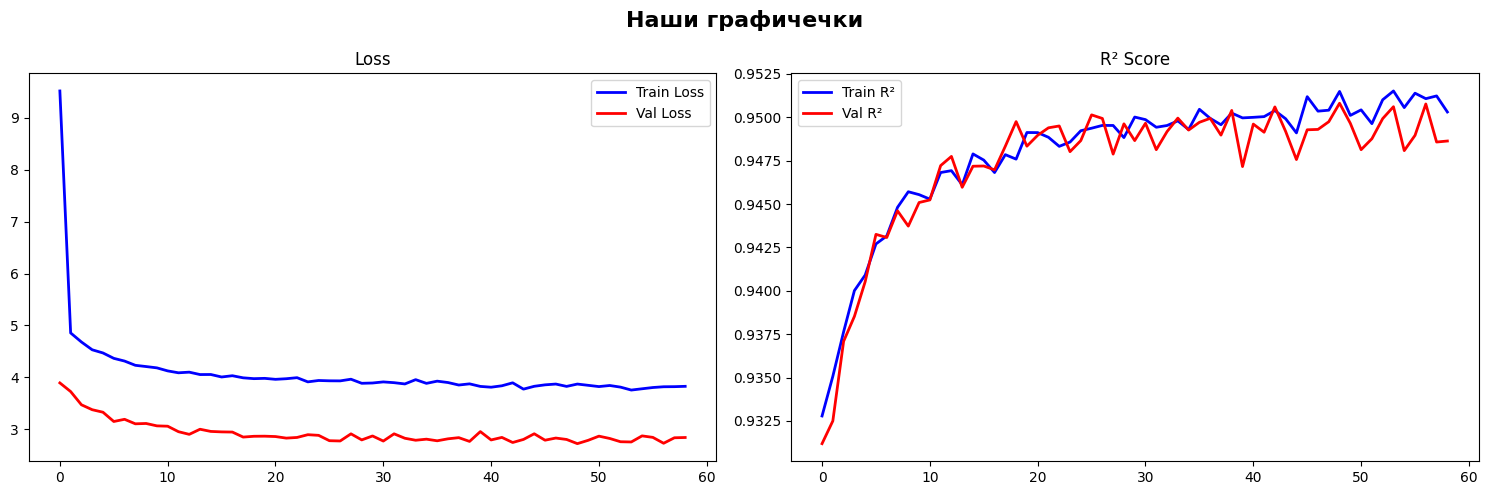

Epoch 59/100
Train Loss: 3.8269 | Val Loss: 2.8410
Train R²: 0.9503 | Val R²: 0.9486
Learning Rate: 0.000454
Best Val Loss: 2.7227

Early stopping triggered


In [39]:
batch_size = 64
epochs = 100

train_loss_history = []
val_loss_history = []
train_r2_history = []
val_r2_history = []
lr_history = []

for epoch in range(epochs):

    #обучение
    epoch_loss = 0

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        optimizer.zero_grad()
        y_pred = model.forward(X_batch)
        loss = criterion.forward(y_pred, y_batch)
        grad_output = criterion.backward(y_pred, y_batch)
        model.backward(X_batch, grad_output)

        optimizer.step()

        epoch_loss += loss

    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_loss_history.append(avg_train_loss)

    train_pred = model.forward(X_train)
    train_r2 = r2_score(y_train, train_pred)
    train_r2_history.append(train_r2)

    val_pred = model.forward(X_val)
    val_loss = criterion.forward(val_pred, y_val)
    val_loss_history.append(val_loss)

    val_r2 = r2_score(y_val, val_pred)
    val_r2_history.append(val_r2)

    stop = early_stopping.step(val_loss, model)

    scheduler.step()
    lr_history.append(optimizer.lr)

    #графички
    if epoch % 5 == 0 or epoch == epochs - 1 or stop:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle('Наши графичечки', fontsize=16, fontweight='bold')
        # Loss
        ax1.plot(train_loss_history, label='Train Loss', color='blue', linewidth=2)
        ax1.plot(val_loss_history, label='Val Loss', color='red', linewidth=2)
        ax1.set_title('Loss')
        ax1.legend()

        # R2
        ax2.plot(train_r2_history, label='Train R²', color='blue', linewidth=2)
        ax2.plot(val_r2_history, label='Val R²', color='red', linewidth=2)
        ax2.set_title('R² Score')
        ax2.legend()

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
        print(f"Learning Rate: {optimizer.lr:.6f}")
        print(f"Best Val Loss: {early_stopping.best_loss:.4f}")

    # остановка
    if stop:
        print("\nEarly stopping triggered")
        break

иожем посмотреть на шедулер

Test Loss: 2.7338 | Test R²: 0.9496
Best Validation Loss: 2.7227 at epoch 1


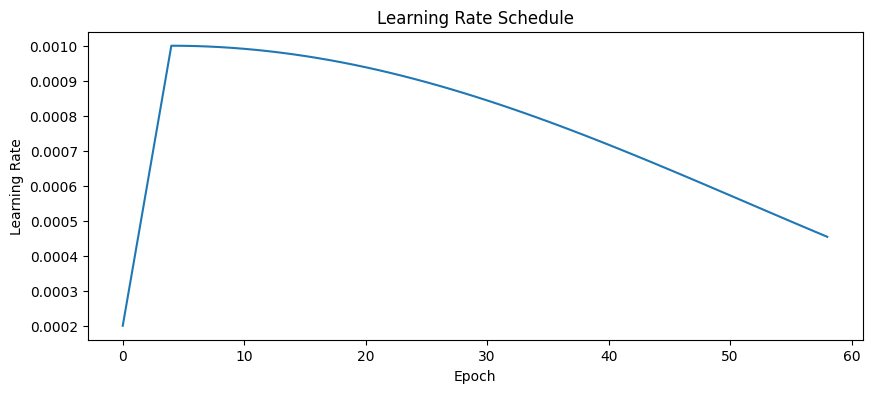

In [40]:
model.evaluate()
test_pred = model.forward(X_test)
test_loss = criterion.forward(test_pred, y_test)
test_r2 = r2_score(y_test, test_pred)

print(f"Test Loss: {test_loss:.4f} | Test R²: {test_r2:.4f}")
print(f"Best Validation Loss: {early_stopping.best_loss:.4f} at epoch {early_stopping.best_epoch+1}")

plt.figure(figsize=(10, 4))
fig.suptitle('Графичечек', fontsize=16, fontweight='bold')
plt.plot(lr_history)
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.show()

перейдем к средней модельке

In [41]:
class MediumRegressionModel(Module):
    def __init__(self, input_dim, hidden_dim=128, out_dim=3, drop_rate=0.3):
        super().__init__()
        self.network = Sequential()

        # Блок 1
        self.network.add(Linear(input_dim, hidden_dim))
        self.network.add(BatchNormalization(hidden_dim))
        self.network.add(LeakyReLU(slope=0.1))
        self.network.add(Dropout(drop_rate))

        # Блок 2
        self.network.add(Linear(hidden_dim, hidden_dim//2))
        self.network.add(BatchNormalization(hidden_dim//2))
        self.network.add(ELU(alpha=1.0))
        self.network.add(Dropout(drop_rate))

        # Блок 3
        self.network.add(Linear(hidden_dim//2, hidden_dim//4))
        self.network.add(BatchNormalization(hidden_dim//4))
        self.network.add(Gelu())
        self.network.add(Dropout(drop_rate))

        # Выход
        self.network.add(Linear(hidden_dim//4, out_dim))
        self.layers = self.network

    def forward(self, x):
        return self.network.forward(x)

    def backward(self, x, grad):
        return self.network.backward(x, grad)

    def getParameters(self):
        params = []
        for layer in self.network.modules:
            if hasattr(layer, 'getParameters'):
                params.extend(layer.getParameters())
        return params

    def setParameters(self, params):
        idx = 0
        for layer in self.network.modules:
            if hasattr(layer, 'getParameters'):
                layer_params = layer.getParameters()
                for i in range(len(layer_params)):
                    layer_params[i][:] = params[idx]
                    idx += 1

In [42]:
model = MediumRegressionModel(input_dim=n_features)
criterion = MSECriterion()
optimizer = SGD(model, lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=100)
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

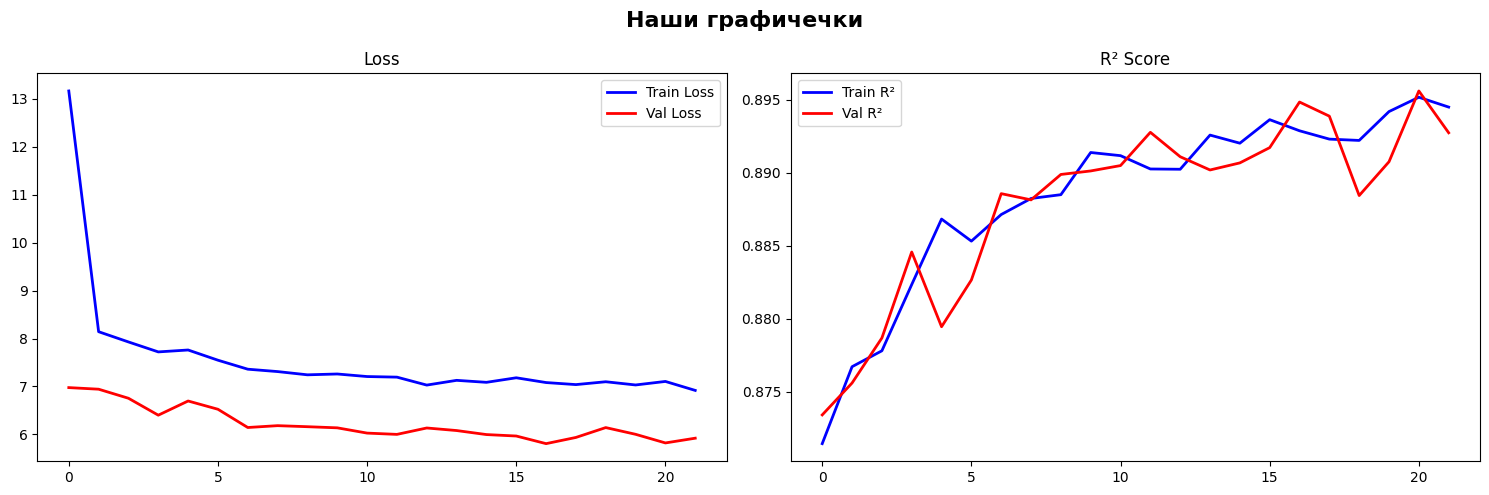

Epoch 22/100
Train Loss: 6.9180 | Val Loss: 5.9214
Train R²: 0.8945 | Val R²: 0.8927
Learning Rate: 0.000923
Best Val Loss: 5.8076

Early stopping triggered


In [43]:
batch_size = 64
epochs = 100

train_loss_history = []
val_loss_history = []
train_r2_history = []
val_r2_history = []
lr_history = []

for epoch in range(epochs):

    #обучение
    epoch_loss = 0

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        optimizer.zero_grad()
        y_pred = model.forward(X_batch)
        loss = criterion.forward(y_pred, y_batch)
        grad_output = criterion.backward(y_pred, y_batch)
        model.backward(X_batch, grad_output)

        optimizer.step()

        epoch_loss += loss

    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_loss_history.append(avg_train_loss)

    train_pred = model.forward(X_train)
    train_r2 = r2_score(y_train, train_pred)
    train_r2_history.append(train_r2)

    val_pred = model.forward(X_val)
    val_loss = criterion.forward(val_pred, y_val)
    val_loss_history.append(val_loss)

    val_r2 = r2_score(y_val, val_pred)
    val_r2_history.append(val_r2)

    stop = early_stopping.step(val_loss, model)

    scheduler.step()
    lr_history.append(optimizer.lr)

    #графички
    if epoch % 5 == 0 or epoch == epochs - 1 or stop:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle('Наши графичечки', fontsize=16, fontweight='bold')

        # Loss
        ax1.plot(train_loss_history, label='Train Loss', color='blue', linewidth=2)
        ax1.plot(val_loss_history, label='Val Loss', color='red', linewidth=2)
        ax1.set_title('Loss')
        ax1.legend()

        # R2
        ax2.plot(train_r2_history, label='Train R²', color='blue', linewidth=2)
        ax2.plot(val_r2_history, label='Val R²', color='red', linewidth=2)
        ax2.set_title('R² Score')
        ax2.legend()

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
        print(f"Learning Rate: {optimizer.lr:.6f}")
        print(f"Best Val Loss: {early_stopping.best_loss:.4f}")

    # остановка
    if stop:
        print("\nEarly stopping triggered")
        break

ну и большая моделька

In [44]:
class LargeRegressionModel(Module):
    def __init__(self, input_size, hidden_size=256, output_size=3, dropout_p=0.4):
        super().__init__()
        self.layers = Sequential()

        # Первый слой
        self.layers.add(Linear(input_size, hidden_size))
        self.layers.add(BatchNormalization(hidden_size))
        self.layers.add(ReLU())
        self.layers.add(Dropout(dropout_p))

        # Второй слой
        self.layers.add(Linear(hidden_size, hidden_size))
        self.layers.add(BatchNormalization(hidden_size))
        self.layers.add(Gelu())
        self.layers.add(Dropout(dropout_p))

        # Третий слой
        self.layers.add(Linear(hidden_size, hidden_size//2))
        self.layers.add(BatchNormalization(hidden_size//2))
        self.layers.add(ELU(alpha=1.0))
        self.layers.add(Dropout(dropout_p))

        # Четвертый слой
        self.layers.add(Linear(hidden_size//2, hidden_size//4))
        self.layers.add(BatchNormalization(hidden_size//4))
        self.layers.add(LeakyReLU(slope=0.1))
        self.layers.add(Dropout(dropout_p))

        # Выходной слой
        self.layers.add(Linear(hidden_size//4, output_size))

    def forward(self, x):
        return self.layers.forward(x)

    def backward(self, x, grad_output):
        return self.layers.backward(x, grad_output)

    def getParameters(self):
        params = []
        for module in self.layers.modules:
            if hasattr(module, 'getParameters'):
                params.extend(module.getParameters())
        return params

    def setParameters(self, new_params):
        idx = 0
        for module in self.layers.modules:
            if hasattr(module, 'getParameters'):
                module_params = module.getParameters()
                for i in range(len(module_params)):
                    module_params[i][:] = new_params[idx]
                    idx += 1

In [45]:
model = LargeRegressionModel(
    input_size=n_features,
    hidden_size=256,
    output_size=n_targets,
    dropout_p=0.3
)

criterion = MSECriterion()
optimizer = SGD(model, lr=0.001, momentum=0.9)
scheduler = CosineAnnealingLR(optimizer, T_max=100, warmup_epochs=5, eta_min=0.0001)
early_stopping = EarlyStopping(patience=10, min_delta=0.001)


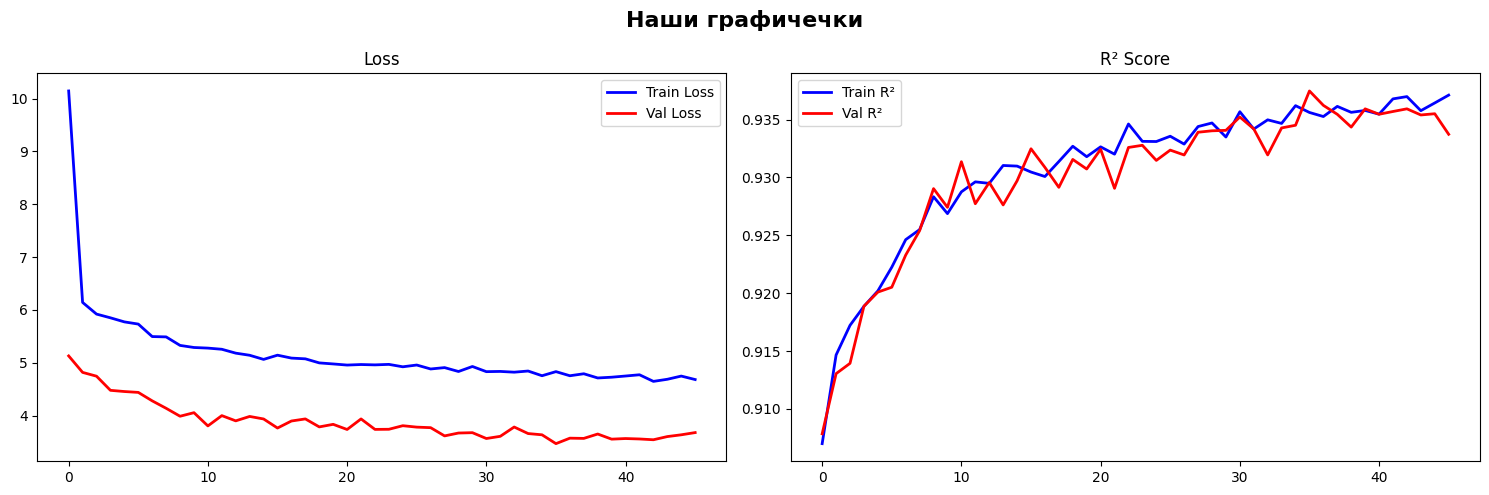

Epoch 46/100
Train Loss: 4.6821 | Val Loss: 3.6783
Train R²: 0.9371 | Val R²: 0.9337
Learning Rate: 0.000646
Best Val Loss: 3.4689

Early stopping triggered


In [46]:
batch_size = 64
epochs = 100

train_loss_history = []
val_loss_history = []
train_r2_history = []
val_r2_history = []
lr_history = []

for epoch in range(epochs):


    epoch_loss = 0

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        optimizer.zero_grad()

        y_pred = model.forward(X_batch)


        loss = criterion.forward(y_pred, y_batch)

        grad_output = criterion.backward(y_pred, y_batch)
        model.backward(X_batch, grad_output)

        optimizer.step()

        epoch_loss += loss

    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_loss_history.append(avg_train_loss)


    train_pred = model.forward(X_train)
    train_r2 = r2_score(y_train, train_pred)
    train_r2_history.append(train_r2)


    val_pred = model.forward(X_val)
    val_loss = criterion.forward(val_pred, y_val)
    val_loss_history.append(val_loss)

    val_r2 = r2_score(y_val, val_pred)
    val_r2_history.append(val_r2)


    stop = early_stopping.step(val_loss, model)


    scheduler.step()
    lr_history.append(optimizer.lr)


    if epoch % 5 == 0 or epoch == epochs - 1 or stop:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle('Наши графичечки', fontsize=16, fontweight='bold')

        # Loss
        ax1.plot(train_loss_history, label='Train Loss', color='blue', linewidth=2)
        ax1.plot(val_loss_history, label='Val Loss', color='red', linewidth=2)
        ax1.set_title('Loss')
        ax1.legend()

        # R2
        ax2.plot(train_r2_history, label='Train R²', color='blue', linewidth=2)
        ax2.plot(val_r2_history, label='Val R²', color='red', linewidth=2)
        ax2.set_title('R² Score')
        ax2.legend()

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
        print(f"Learning Rate: {optimizer.lr:.6f}")
        print(f"Best Val Loss: {early_stopping.best_loss:.4f}")

    # остановка
    if stop:
        print("\nEarly stopping triggered")
        break

### MNIST

Реализуем мулитиклассификацию

In [47]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

данные

In [58]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype('float32') / 255.0
y = mnist.target.astype('int')

данных оч много, поэтому возьмем небольшой кусок выборкм

In [59]:
sample_size = 5000
indices = np.random.choice(len(X), sample_size, replace=False)
X = X[indices]
y = y[indices]

In [60]:
def onehot(y, num_classes=10):
    return np.eye(num_classes)[y]
y_onehot = onehot(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_onehot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.7, random_state=42)

посмотрим на данные

In [61]:
print("Train shapes:", X_train.shape, y_train.shape)
print("Val shapes:", X_val.shape, y_val.shape)
print("Test shapes:", X_test.shape, y_test.shape)
print("Метка пример:", y_train[0], "->", np.argmax(y_train[0]))

Train shapes: (3500, 784) (3500, 10)
Val shapes: (450, 784) (450, 10)
Test shapes: (1050, 784) (1050, 10)
Метка пример: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.] -> 3


наша сеть

In [62]:
class MNISTClassifier(Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10, dropout_p=0.3):
        super().__init__()
        self.layers = Sequential()

        self.layers.add(Linear(input_size, hidden_size))
        self.layers.add(BatchNormalization())
        self.layers.add(ReLU())
        self.layers.add(Dropout(dropout_p))

        self.layers.add(Linear(hidden_size, num_classes))
        self.layers.add(SoftMax())

    def forward(self, x):
        return self.layers.forward(x)

    def backward(self, x, grad_output):
        return self.layers.backward(x, grad_output)

    def getParameters(self):
        params = []
        for module in self.layers.modules:
            if hasattr(module, 'getParameters'):
                params.extend(module.getParameters())
        return params

    def setParameters(self, new_params):
        idx = 0
        for module in self.layers.modules:
            if hasattr(module, 'getParameters'):
                module_params = module.getParameters()
                for i in range(len(module_params)):
                    module_params[i][:] = new_params[idx]
                    idx += 1

In [63]:
model = MNISTClassifier(input_size=784, hidden_size=256)
criterion = MSECriterion()
optimizer = SGD(model, lr=0.001, momentum=0.9)
scheduler = CosineAnnealingLR(optimizer, T_max=100, warmup_epochs=5, eta_min=0.0001)
early_stopping = EarlyStopping(patience=20, min_delta=0.001)

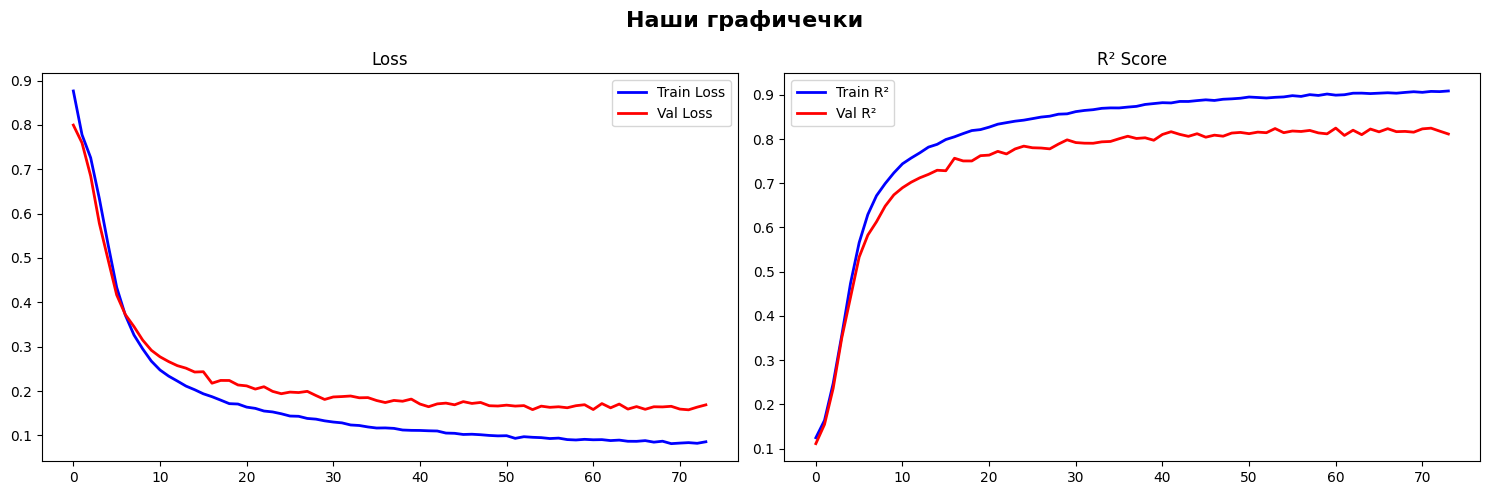

Epoch 74/100
Train Loss: 0.0856 | Val Loss: 0.1688
Train R²: 0.9086 | Val R²: 0.8113
Learning Rate: 0.000256
Best Val Loss: 0.1580

Early stopping triggered


In [64]:
batch_size = 64
epochs = 100

train_loss_history = []
val_loss_history = []
train_r2_history = []
val_r2_history = []
lr_history = []

for epoch in range(epochs):

    #обучение
    epoch_loss = 0

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        optimizer.zero_grad()
        y_pred = model.forward(X_batch)
        loss = criterion.forward(y_pred, y_batch)
        grad_output = criterion.backward(y_pred, y_batch)
        model.backward(X_batch, grad_output)

        optimizer.step()

        epoch_loss += loss

    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_loss_history.append(avg_train_loss)

    train_pred = model.forward(X_train)
    train_r2 = r2_score(y_train, train_pred)
    train_r2_history.append(train_r2)

    val_pred = model.forward(X_val)
    val_loss = criterion.forward(val_pred, y_val)
    val_loss_history.append(val_loss)

    val_r2 = r2_score(y_val, val_pred)
    val_r2_history.append(val_r2)

    stop = early_stopping.step(val_loss, model)

    scheduler.step()
    lr_history.append(optimizer.lr)

    #графички
    if epoch % 5 == 0 or epoch == epochs - 1 or stop:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle('Наши графичечки', fontsize=16, fontweight='bold')

        # Loss
        ax1.plot(train_loss_history, label='Train Loss', color='blue', linewidth=2)
        ax1.plot(val_loss_history, label='Val Loss', color='red', linewidth=2)
        ax1.set_title('Loss')
        ax1.legend()

        # R2
        ax2.plot(train_r2_history, label='Train R²', color='blue', linewidth=2)
        ax2.plot(val_r2_history, label='Val R²', color='red', linewidth=2)
        ax2.set_title('R² Score')
        ax2.legend()

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
        print(f"Learning Rate: {optimizer.lr:.6f}")
        print(f"Best Val Loss: {early_stopping.best_loss:.4f}")

    if stop:
        print("\nEarly stopping triggered")
        break

Автоэнкодер

In [65]:
class Autoencoder(Module):
    def __init__(self, input_size=784, hidden_size=256, latent_dim=32, dropout_p=0.3):
        super().__init__()

        self.encoder = Sequential()
        self.encoder.add(Linear(input_size, hidden_size))
        self.encoder.add(BatchNormalization())
        self.encoder.add(ReLU())
        self.encoder.add(Dropout(dropout_p))
        self.encoder.add(Linear(hidden_size, latent_dim))
        self.encoder.add(BatchNormalization())
        self.encoder.add(ReLU())

        self.decoder = Sequential()
        self.decoder.add(Linear(latent_dim, hidden_size))
        self.decoder.add(BatchNormalization())
        self.decoder.add(ReLU())
        self.decoder.add(Dropout(dropout_p))

        self.decoder.add(Linear(hidden_size, input_size))
        self.decoder.add(ReLU())


        self.layers = Sequential()
        self.layers.modules = self.encoder.modules + self.decoder.modules

    def forward(self, x):
        self.encoded = self.encoder.forward(x)
        return self.decoder.forward(self.encoded)

    def backward(self, x, grad_output):
        grad_decoder = self.decoder.backward(self.encoded, grad_output)
        return self.encoder.backward(x, grad_decoder)

    def getParameters(self):
        return self.encoder.getParameters() + self.decoder.getParameters()

ну и обучение

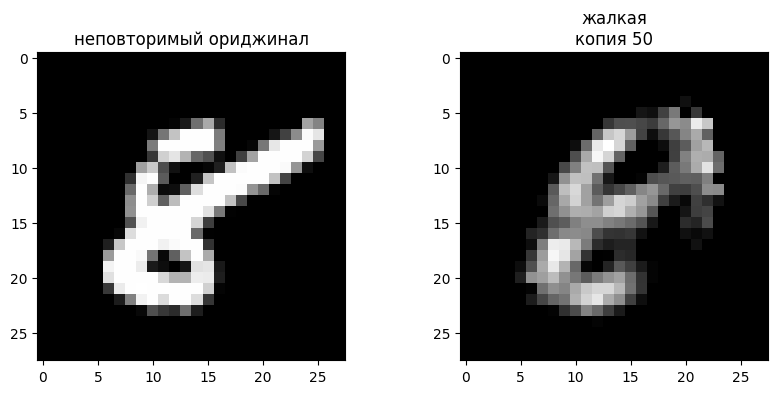

Epoch 50/50 | Train Loss: 16.0470


In [67]:
model = Autoencoder(input_size=784, hidden_size=512, latent_dim=64)
criterion = MSECriterion()
optimizer = SGD(model, lr=0.0005)
batch_size = 128
epochs = 50


for epoch in range(epochs):
    model.train()
    train_loss = 0

    for i in range(0, len(X_train), batch_size):
        batch = X_train[i:i+batch_size]

        optimizer.zero_grad()
        reconstructed = model.forward(batch)
        loss = criterion.forward(reconstructed, batch)
        grad = criterion.backward(reconstructed, batch)
        model.backward(batch, grad)
        optimizer.step()

        train_loss += loss


    if epoch % 5 == 0 or epoch == epochs - 1:
        model.evaluate()
        val_reconstructed = model.forward(X_val[:5])

        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        fig.suptitle('В ее глазах это было круто, надеюся в ваших тоже', fontsize=16, fontweight='bold')
        #неповторимый ориджинал
        plt.subplot(1, 2, 1)
        plt.imshow(X_val[0].reshape(28, 28), cmap='gray')
        plt.title('неповторимый ориджинал')

        #жалкая копия
        plt.subplot(1, 2, 2)
        plt.imshow(val_reconstructed[0].reshape(28, 28), cmap='gray')
        plt.title(f'жалкая\nкопия {epoch+1}')

        plt.show()
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/(len(X_train)/batch_size):.4f}")